# Quantitative Trading Architecture: Cross-Asset Multi-Frequency Fusion

## Overview
This notebook implements an end-to-end deep learning framework for **Reversal Zone (Peak & Trough) Detection** on the Hang Seng Index (`^HSI`). To increase signal reliability, the model uses peer confirmation from 11 strategic constituent anchors across key Hong Kong equity sectors (Technology, Finance, Energy, Real Estate, etc.).

### Key Architectural Phases
1. **Synchronized Multi-Asset Pipeline**: Temporal same-day alignment across all asset streams with multi-frequency indicator extraction (Micro 14-day vs. Macro 50-day windows).
2. **Base Bayesian Neural Networks**: Individual asset `RegimeGRU` networks trained using Stochastic Gradient Langevin Dynamics (SGLD) with Focal Loss.
3. **Cross-Asset Fusion Model**: An ensemble layer aggregating pre-computed hidden states across 100 expert SGLD snapshots per asset.
4. **GPU Accuracy Grid Search**: Uncertainty-aware binning engine hyperparameter tuning evaluated directly on CUDA VRAM against dual-frequency ground truth targets.
5. **Out-of-Sample Execution & Interactivity**: QuantStats metric evaluation, candlestick backtest plotting via `mplfinance`, and a $\binom{13}{2} = 78$ combination decision surface dashboard.

In [1]:
!pip install -q TA-Lib mplfinance quantstats seaborn scikit-learn yfinance

import math
import copy
import os
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import talib
from scipy.signal import find_peaks
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import os
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
import mplfinance as mpf
import quantstats as qs
from google.colab import drive

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {DEVICE}")

Using compute device: cuda


## Phase I: Synchronized Multi-Asset Data Pipeline

### Methodology
- **Data Alignment**: Ingests daily market data for `^HSI` and 11 sector anchors. Intersects trading calendar dates to guarantee strict same-day temporal alignment across all input vectors.
- **Multi-Frequency Indicator Extraction**:
  - **Micro Features (14-day)**: RSI, RSI Slope, Fast Stochastic ($K, D$), Price Deviation from 20-day SMA, Volume Burst ratio, and Return Acceleration.
  - **Macro Features (50-day)**: RSI, Fast Stochastic ($K, D$), Price Deviation from 200-day SMA, Volume Base ratio, and Return Velocity (10-day price shift).
- **Ground Truth Target Extraction**: Uses `scipy.signal.find_peaks` on raw closing prices with structural prominence thresholds to mark major structural swings (Major) and shorter-term cyclical turns (Minor):
  - Class `0`: Trough / Buy Zone
  - Class `1`: Peak / Sell Zone
  - Class `2`: Neutral / Trend

In [2]:
class SynchronizedMultiAssetPipeline:
    def __init__(self, tickers, start_date, end_date, time_steps=10):
        self.tickers = tickers
        self.start_date = pd.to_datetime(start_date) - pd.Timedelta(days=400)
        self.end_date = end_date
        self.time_steps = time_steps

        self.micro_cols = ['Micro_RSI', 'Micro_RSI_Slope', 'Micro_FastK', 'Micro_FastD', 'Micro_Prc_Dev', 'Micro_Vol_Burst', 'Micro_Ret_Accel']
        self.macro_cols = ['Macro_RSI', 'Macro_FastK', 'Macro_FastD', 'Macro_Prc_Dev', 'Macro_Vol_Base', 'Macro_Ret_Vel']
        self.feature_columns = self.micro_cols + self.macro_cols

    def compute_features(self, df):
        df['Micro_RSI'] = talib.RSI(df['Close'], timeperiod=14) / 100.0
        df['Micro_RSI_Slope'] = df['Micro_RSI'].diff(3)
        fastk, fastd = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=5, fastd_period=3, fastd_matype=0)
        df['Micro_FastK'] = fastk / 100.0
        df['Micro_FastD'] = fastd / 100.0
        sma_20 = talib.SMA(df['Close'], timeperiod=20)
        df['Micro_Prc_Dev'] = (df['Close'] / sma_20) - 1.0
        sma_vol_20 = talib.SMA(df['Volume'], timeperiod=20).replace(0, np.nan)
        df['Micro_Vol_Burst'] = (df['Volume'] / sma_vol_20).fillna(1.0)
        df['Micro_Ret_Accel'] = df['Close'].pct_change() - df['Close'].pct_change().rolling(window=5).mean()

        df['Macro_RSI'] = talib.RSI(df['Close'], timeperiod=50) / 100.0
        fastk_m, fastd_m = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=20, fastd_period=5, fastd_matype=0)
        df['Macro_FastK'] = fastk_m / 100.0
        df['Macro_FastD'] = fastd_m / 100.0
        sma_200 = talib.SMA(df['Close'], timeperiod=200)
        df['Macro_Prc_Dev'] = (df['Close'] / sma_200) - 1.0
        sma_vol_100 = talib.SMA(df['Volume'], timeperiod=100).replace(0, np.nan)
        df['Macro_Vol_Base'] = (sma_vol_20 / sma_vol_100).fillna(1.0)
        df['Macro_Ret_Vel'] = df['Close'] / df['Close'].shift(10) - 1.0

        df['5D_MA'] = talib.SMA(df['Close'], timeperiod=5)
        df['20D_MA'] = sma_20
        return df.fillna(0)

    def generate_labels(self, df):
        prices = df['Close'].values
        mean_price = np.nanmean(prices)
        min_prominence = mean_price * 0.03

        peaks, _ = find_peaks(prices, distance=1, prominence=min_prominence)
        troughs, _ = find_peaks(-prices, distance=1, prominence=min_prominence)

        labels = np.full(len(prices), 2)
        for p in peaks: labels[p] = 1
        for t in troughs: labels[t] = 0

        df['Regime'] = labels
        return df.dropna()

    def generate_minor_labels(self, df):
        prices = df['Close'].values
        mean_price = np.nanmean(prices)
        min_prominence = mean_price * 0.01

        peaks, _ = find_peaks(prices, distance=1, prominence=min_prominence)
        troughs, _ = find_peaks(-prices, distance=1, prominence=min_prominence)

        labels = np.full(len(prices), 2)
        for p in peaks: labels[p] = 1
        for t in troughs: labels[t] = 0

        df['Regime'] = labels
        return df.dropna()

    def prepare_all_data(self, val_days, test_days, minor=False):
        processed_data = {}
        common_index = None

        for name, ticker in self.tickers.items():
            df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            df = self.compute_features(df)
            df = self.generate_minor_labels(df) if minor else self.generate_labels(df)
            processed_data[name] = df

            common_index = df.index if common_index is None else common_index.intersection(df.index)

        for name in processed_data:
            processed_data[name] = processed_data[name].loc[common_index]

        datasets = {}
        for name, df in processed_data.items():
            features = df[self.feature_columns].values
            labels = df['Regime'].values

            X, Y = [], []
            for i in range(len(features) - self.time_steps + 1):
                X.append(features[i:(i + self.time_steps)])
                Y.append(labels[i + self.time_steps - 1])

            X, Y = np.array(X), np.array(Y, dtype=np.int64)

            test_idx = len(X) - test_days
            val_idx = test_idx - val_days

            X_train, X_val, X_test = X[:val_idx], X[val_idx:test_idx], X[test_idx:]
            Y_train, Y_val, Y_test = Y[:val_idx], Y[val_idx:test_idx], Y[test_idx:]

            scaler = StandardScaler()
            B, T, F_dim = X_train.shape
            X_train_reshaped = X_train.reshape(-1, F_dim)
            scaler.fit(X_train_reshaped)

            datasets[name] = {
                'X_train': scaler.transform(X_train_reshaped).reshape(B, T, F_dim),
                'X_val': scaler.transform(X_val.reshape(-1, F_dim)).reshape(X_val.shape[0], T, F_dim),
                'X_test': scaler.transform(X_test.reshape(-1, F_dim)).reshape(X_test.shape[0], T, F_dim),
                'Y_train': Y_train, 'Y_val': Y_val, 'Y_test': Y_test,
                'clean_df': df.iloc[-len(X):].copy(),
                'scaler': scaler
            }

        return datasets

# --- EXECUTION ---
TICKERS_MAP = {
    "Target": "^HSI", "TechAnchor": "0700.HK"
    , "FinanceAnchor": "0388.HK",
    "PropertyAnchor": "0016.HK", "EnergyAnchor": "0883.HK", "TelecomAnchor": "0941.HK",
    "BankingAnchor": "0005.HK", "InsuranceAnchor": "2318.HK", "UtilityAnchor": "0002.HK",
    "MaterialsAnchor": "2899.HK", "AutoAnchor": "0175.HK", "ConglomerateAnchor": "0001.HK"
}

START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
VAL_DAYS_N = 504
TEST_DAYS_N = 504
TIME_STEPS = 20

print("Preparing Synchronized Multi-Asset Pipeline...")
multi_pipeline = SynchronizedMultiAssetPipeline(tickers=TICKERS_MAP, start_date=START_DATE, end_date=END_DATE, time_steps=TIME_STEPS)
multi_data = multi_pipeline.prepare_all_data(val_days=VAL_DAYS_N, test_days=TEST_DAYS_N)
multi_minor_data = multi_pipeline.prepare_all_data(val_days=VAL_DAYS_N, test_days=TEST_DAYS_N, minor=True)

clean_df = multi_data['Target']['clean_df']
clean_minor_df = multi_minor_data['Target']['clean_df']
X_train_hsi, X_val_hsi, X_test_hsi = multi_data['Target']['X_train'], multi_data['Target']['X_val'], multi_data['Target']['X_test']
Y_train_hsi, Y_val_hsi, Y_test_hsi = multi_data['Target']['Y_train'], multi_data['Target']['Y_val'], multi_data['Target']['Y_test']

Preparing Synchronized Multi-Asset Pipeline...


## Phase Ib: Ground Truth Label Verification

### Explanation
Before model training, we plot the extracted price extrema over the target asset (`^HSI`). This visual sanity check confirms that the prominence algorithms correctly identify major macro reversals (green triangles for troughs, red triangles for peaks) without creating spurious label clusters during choppy consolidation periods.


--- LABEL VERIFICATION: Review Ground Truth Mapping ---


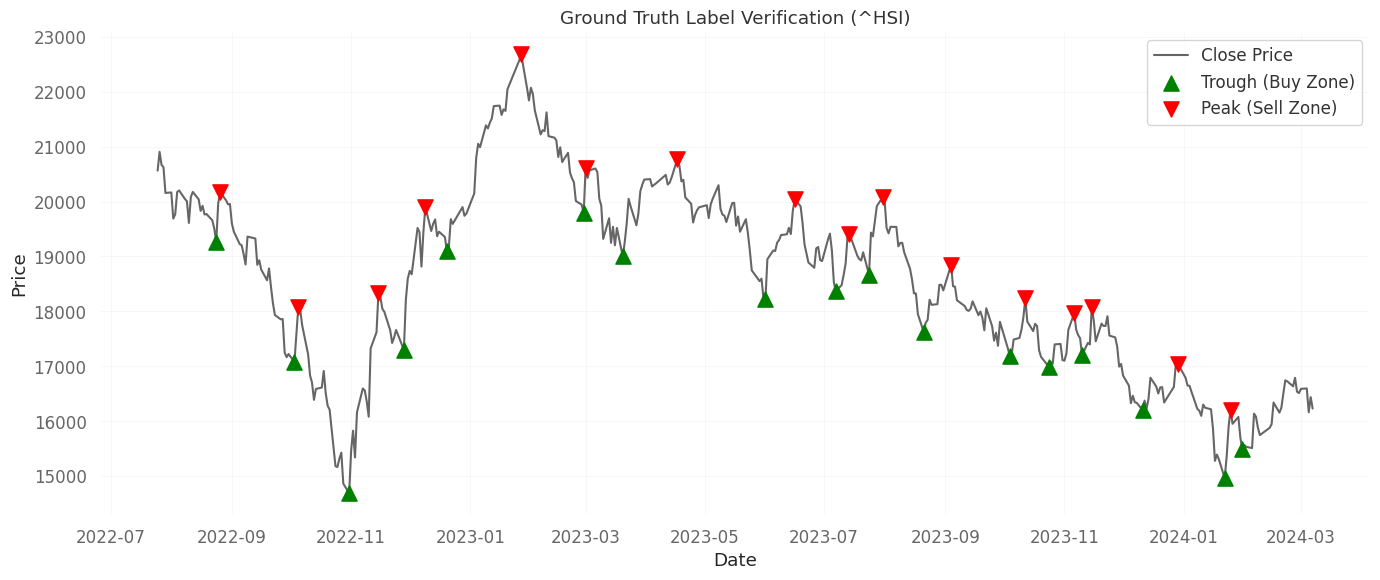


--- LABEL VERIFICATION: Review Ground Truth Mapping ---


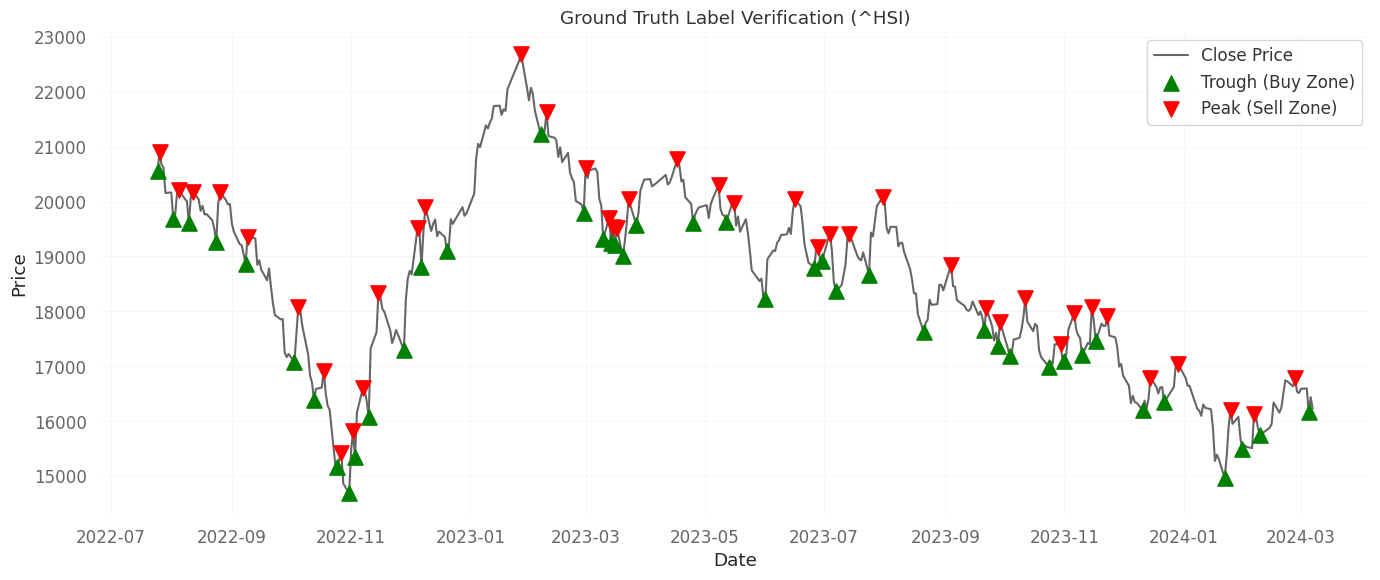

In [3]:
def plot_label_verification(df, start_idx=-400, end_idx=-100):
    print("\n--- LABEL VERIFICATION: Review Ground Truth Mapping ---")
    plot_df = df.iloc[start_idx:end_idx].copy()

    plt.figure(figsize=(14, 6))
    plt.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black', alpha=0.6)
    troughs = plot_df[plot_df['Regime'] == 0]
    plt.scatter(troughs.index, troughs['Close'], color='green', marker='^', s=120, label='Trough (Buy Zone)', zorder=5)
    peaks = plot_df[plot_df['Regime'] == 1]
    plt.scatter(peaks.index, peaks['Close'], color='red', marker='v', s=120, label='Peak (Sell Zone)', zorder=5)

    plt.title('Ground Truth Label Verification (^HSI)')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_label_verification(clean_df, start_idx=-600, end_idx=-200)
plot_label_verification(clean_minor_df, start_idx=-600, end_idx=-200)

## Phase II: Base Neural Architecture & SGLD Snapshot Training

### Methodology
- **RegimeGRU Architecture**: Features a bottleneck linear embedding layer ($13 \to 8$), followed by a 1-layer GRU (hidden dim 32) and a 3-class linear classifier.
- **Focal Loss**: Replaces standard Cross-Entropy Loss to heavily penalize class imbalance and force gradient emphasis onto rare extrema transitions.
  $$\text{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$
- **3-Phase SGLD Expert Generation**:
  1. **Phase 1 (Pure Fitting)**: Pre-trains base parameters via Adam optimizer.
  2. **Phase 2 (Goldilocks Transition)**: Switches to SGD and injects controlled Gaussian noise to escape local minima.
  3. **Phase 3 (Snapshot Sampling)**: Collects 100 SGLD expert state dicts per asset across an ergodic Markov chain trajectory.


--- CHECKPOINT 1: Training Individual Asset Base Models ---
Training base model for Target...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.0967
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0687
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0355
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0158
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0152
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0170
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0177
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0176
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0178
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0214
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0222
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0195
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0187


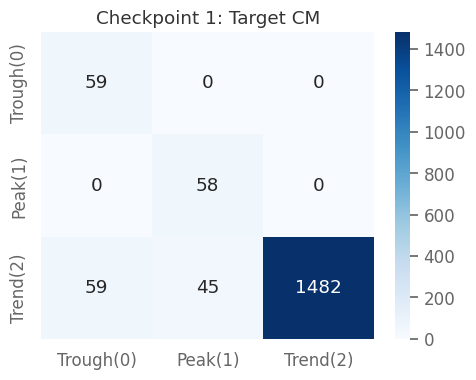

Training base model for TechAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.1092
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0673
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0324
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0116
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0119
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0127
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0142
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0161
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0166
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0185
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0166
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0168
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0191


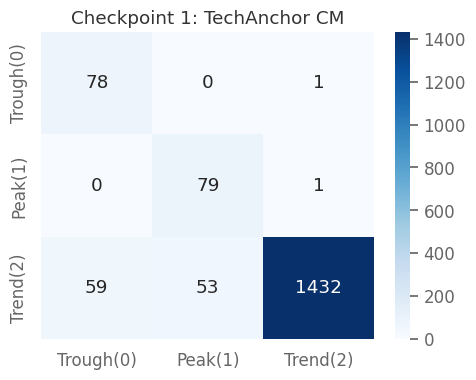

Training base model for FinanceAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.0921
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0657
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0430
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0254
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0245
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0249
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0267
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0279
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0282
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0266
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0270
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0277
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0289


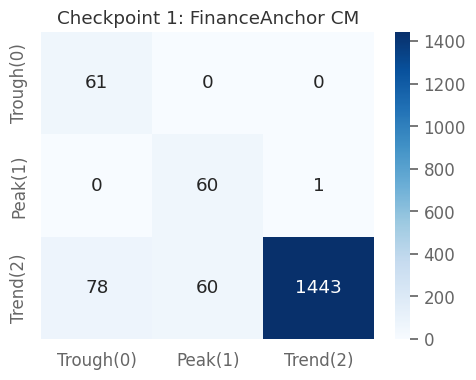

Training base model for PropertyAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.0975
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0632
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0257
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0109
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0145
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0135
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0134
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0143
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0140
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0158
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0160
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0174
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0362


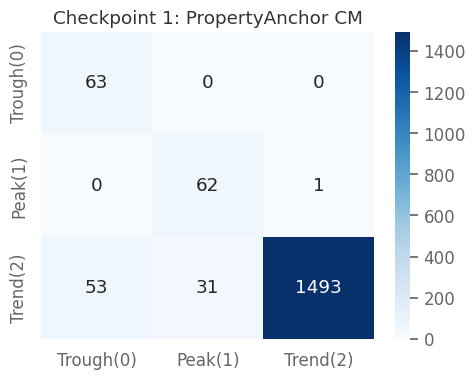

Training base model for EnergyAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.1018
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0736
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0480
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0302
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0303
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0302
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0309
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0319
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0321
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0376
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0341
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0360
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0370


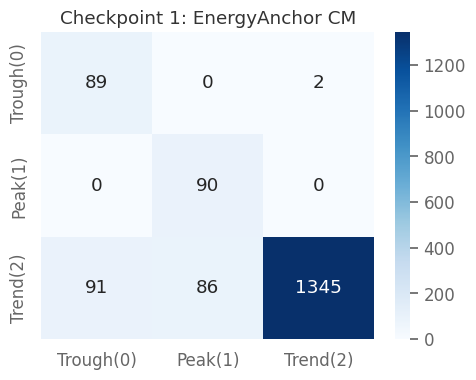

Training base model for TelecomAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.0968
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0727
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0392
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0193
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0184
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0193
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0214
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0212
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0210
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0219
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0211
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0246
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0238


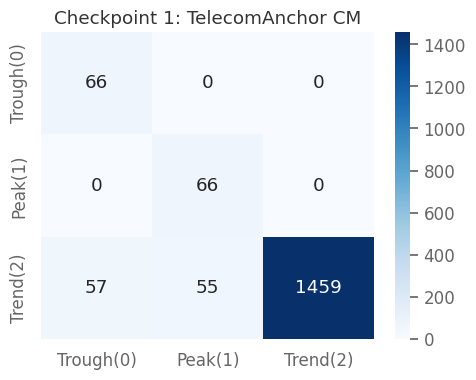

Training base model for BankingAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.0925
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0696
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0425
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0225
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0229
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0228
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0237
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0243
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0244
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0284
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0280
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0281
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0278


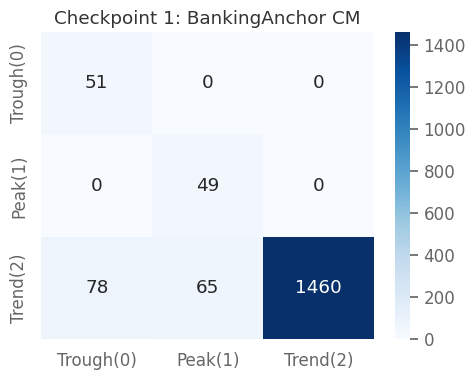

Training base model for InsuranceAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.0997
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0693
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0371
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0132
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0135
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0144
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0155
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0154
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0155
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0158
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0179
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0182
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0198


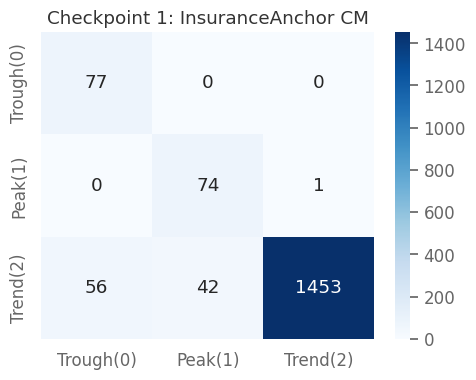

Training base model for UtilityAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.0863
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0520
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0263
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0143
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0136
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0150
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0153
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0159
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0159
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0171
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0156
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0163
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0182


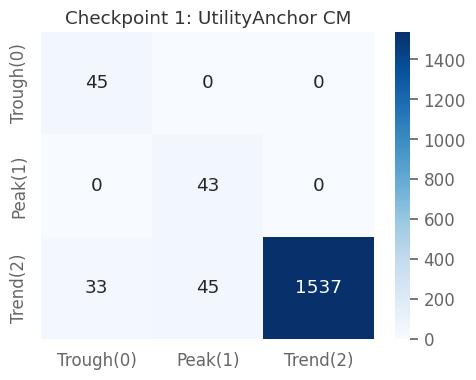

Training base model for MaterialsAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.0857
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0515
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0176
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0049
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0062
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0064
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0076
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0100
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0103
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0097
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0089
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0106
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0141


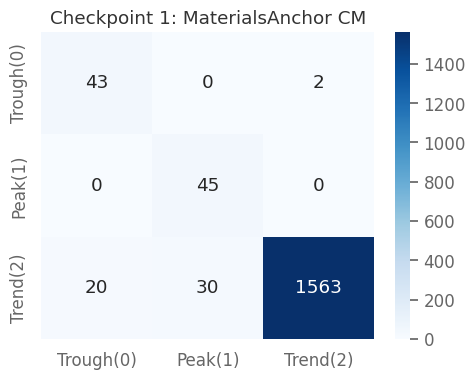

Training base model for AutoAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.1190
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0813
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0511
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0283
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0284
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0303
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0323
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0340
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0340
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0361
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0367
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0380
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0373


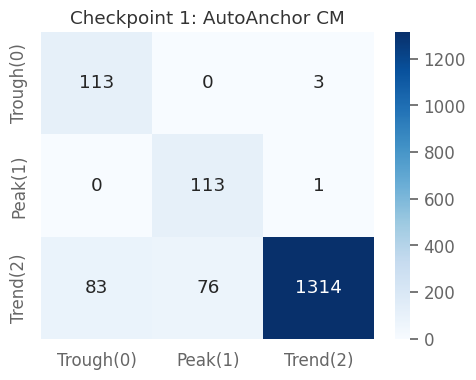

Training base model for ConglomerateAnchor...
   [Phase 1 Adam] Epoch 100/400 | Loss: 0.1019
   [Phase 1 Adam] Epoch 200/400 | Loss: 0.0794
   [Phase 1 Adam] Epoch 300/400 | Loss: 0.0531
   [Phase 1 Adam] Epoch 400/400 | Loss: 0.0267
   [Phase 2 Transition] Epoch 50/200 | Loss: 0.0264
   [Phase 2 Transition] Epoch 100/200 | Loss: 0.0277
   [Phase 2 Transition] Epoch 150/200 | Loss: 0.0292
   [Phase 2 Transition] Epoch 200/200 | Loss: 0.0282
   [Phase 3 SGLD] Snapshot 1/100 (Epoch 0) | Loss: 0.0282
   [Phase 3 SGLD] Snapshot 20/100 (Epoch 95) | Loss: 0.0298
   [Phase 3 SGLD] Snapshot 40/100 (Epoch 195) | Loss: 0.0314
   [Phase 3 SGLD] Snapshot 60/100 (Epoch 295) | Loss: 0.0319
   [Phase 3 SGLD] Snapshot 80/100 (Epoch 395) | Loss: 0.0319


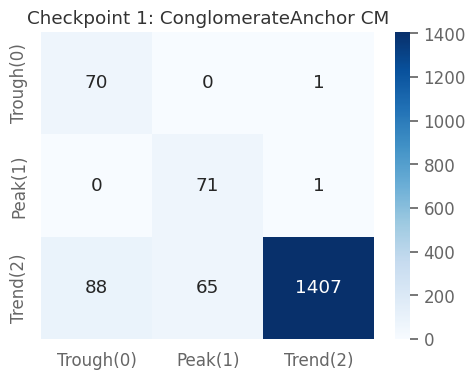

In [4]:
class RegimeGRU(nn.Module):
    def __init__(self, input_features=13, hidden_dim=16, output_classes=3):
        super(RegimeGRU, self).__init__()
        self.bottleneck_dim = max(4, (input_features // 2) + 2)
        self.embedding = nn.Linear(input_features, self.bottleneck_dim)
        self.gru = nn.GRU(self.bottleneck_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_classes)

    def get_hidden_state(self, x):
        embedded_x = torch.relu(self.embedding(x))
        out, _ = self.gru(embedded_x)
        return out[:, -1, :]

    def forward(self, x):
        final_state = self.get_hidden_state(x)
        logits = self.fc(final_state)
        return logits, final_state

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_term = (1 - pt) ** self.gamma
        loss = focal_term * ce_loss

        if self.alpha is not None:
            loss = self.alpha[targets] * loss

        return loss.mean() if self.reduction == 'mean' else (loss.sum() if self.reduction == 'sum' else loss)

def train_base_model_sgld(model, X_train, Y_train, fit_epochs=400, transition_epochs=200, snapshot_step=5, n_snapshots=100, verbose=True):
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=96, shuffle=True)

    class_counts = np.bincount(Y_train)
    basic_weights = len(Y_train) / (len(class_counts) * class_counts)
    class_weights = torch.tensor(basic_weights, dtype=torch.float32).to(DEVICE)
    criterion = FocalLoss(alpha=class_weights, gamma=2.0)

    experts = []

    # Phase 1: Pure Fitting
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    model.train()
    for epoch in range(fit_epochs):
        epoch_loss, n_batches = 0.0, 0
        for bx, by in loader:
            optimizer_adam.zero_grad()
            logits, _ = model(bx.to(DEVICE))
            loss = criterion(logits, by.to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_adam.step()
            epoch_loss += loss.item()
            n_batches += 1

        if verbose and (epoch + 1) % 100 == 0:
            print(f"   [Phase 1 Adam] Epoch {epoch+1}/{fit_epochs} | Loss: {epoch_loss/n_batches:.4f}")

    # Phase 2: Transition
    lr_sgd = 1e-4
    optimizer_sgd = torch.optim.SGD(model.parameters(), lr=lr_sgd, weight_decay=1e-4)
    for epoch in range(transition_epochs):
        epoch_loss, n_batches = 0.0, 0
        for bx, by in loader:
            optimizer_sgd.zero_grad()
            logits, _ = model(bx.to(DEVICE))
            loss = criterion(logits, by.to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_sgd.step()

            with torch.no_grad():
                noise_scale = math.sqrt(2 * lr_sgd) * 0.02
                for param in model.parameters():
                    if param.requires_grad:
                        param.add_(torch.randn_like(param) * noise_scale)
            epoch_loss += loss.item()
            n_batches += 1

        if verbose and (epoch + 1) % 50 == 0:
            print(f"   [Phase 2 Transition] Epoch {epoch+1}/{transition_epochs} | Loss: {epoch_loss/n_batches:.4f}")

    # Phase 3: Snapshot Generation
    snapshot_epochs = (n_snapshots - 1) * snapshot_step
    lr_snapshot = 1e-4
    optimizer_snapshot = torch.optim.SGD(model.parameters(), lr=lr_snapshot, weight_decay=1e-4)
    for epoch in range(snapshot_epochs):
        epoch_loss, n_batches = 0.0, 0
        for bx, by in loader:
            optimizer_snapshot.zero_grad()
            logits, _ = model(bx.to(DEVICE))
            loss = criterion(logits, by.to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_snapshot.step()

            with torch.no_grad():
                noise_scale = math.sqrt(2 * lr_snapshot) * 0.02
                for param in model.parameters():
                    if param.requires_grad:
                        param.add_(torch.randn_like(param) * noise_scale)
            epoch_loss += loss.item()
            n_batches += 1

        if epoch % snapshot_step == 0:
            experts.append(copy.deepcopy(model.state_dict()))
            if verbose and (len(experts) % 20 == 0 or len(experts) == 1 or len(experts) == n_snapshots):
                print(f"   [Phase 3 SGLD] Snapshot {len(experts)}/{n_snapshots} (Epoch {epoch}) | Loss: {epoch_loss/n_batches:.4f}")


    model.eval()
    return experts

def evaluate_and_plot_cm(model, X, Y, title="Confusion Matrix"):
    X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        logits, _ = model(X_tensor)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(Y, preds), annot=True, fmt='d', cmap='Blues',
                xticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'],
                yticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'])
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Train base models across all 12 assets
trained_base_models = {}
print("\n--- CHECKPOINT 1: Training Individual Asset Base Models ---")

for name, d in multi_data.items():
    print(f"Training base model for {name}...")
    m = RegimeGRU(input_features=13, hidden_dim=16).to(DEVICE)
    experts = train_base_model_sgld(model=m, X_train=d['X_train'], Y_train=d['Y_train'])
    trained_base_models[name] = experts
    m.load_state_dict(experts[-1])
    evaluate_and_plot_cm(m, d['X_train'], d['Y_train'], title=f"Checkpoint 1: {name} CM")

## Phase III: Cross-Asset Fusion Layer & Ensemble Aggregation

### Methodology
- **Hidden State Fusion**: Concatenates hidden state representations ($12 \text{ assets} \times 32 \text{ hidden dims} = 384 \text{ dimensions}$) across all assets and snapshots.
- **Epistemic Uncertainty Intervals**: Computes mean predictions along with Upper (top 20%) and Lower (bottom 20%) snapshot tails based on Peak-minus-Trough ranking scores.
- **Training Acceleration**: Pre-computes hidden state caches for training sets to bypass redundant forward passes during fusion layer optimization.


--- TRAINING MULTI-ASSET FUSION LAYER ---


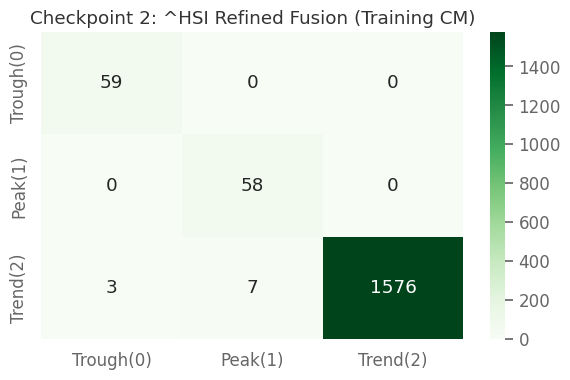

In [5]:
class CrossAssetFusionModel(nn.Module):
    def __init__(self, snapshot_dicts_dict, hidden_dim=16, output_classes=3):
        super(CrossAssetFusionModel, self).__init__()
        self.snapshot_dicts = snapshot_dicts_dict
        self.hidden_dim = hidden_dim
        self.output_classes = output_classes

        self.template_models = nn.ModuleDict()
        for name in snapshot_dicts_dict.keys():
            self.template_models[name] = RegimeGRU(input_features=13, hidden_dim=hidden_dim, output_classes=output_classes)

        for model in self.template_models.values():
            model.eval()
            for p in model.parameters(): p.requires_grad = False

        total_hidden_dim = len(snapshot_dicts_dict) * hidden_dim
        self.fusion_fc = nn.Linear(total_hidden_dim, output_classes)

    def forward(self, x_dict, return_intervals=False):
        asset_names = list(self.snapshot_dicts.keys())
        batch_size = x_dict[asset_names[0]].size(0)

        if not return_intervals:
            fusion_hidden_parts = []
            for name in asset_names:
                x = x_dict[name]
                if x.dim() == 2:
                    fusion_hidden_parts.append(x)
                else:
                    model = self.template_models[name]
                    states = []
                    for s_dict in self.snapshot_dicts[name]:
                        model.load_state_dict(s_dict)
                        with torch.no_grad():
                            states.append(model.get_hidden_state(x))
                    fusion_hidden_parts.append(torch.stack(states, dim=0).mean(dim=0))
            logits = self.fusion_fc(torch.cat(fusion_hidden_parts, dim=1))
            return logits

        else:
            mean_hidden_parts, lower_hidden_parts, upper_hidden_parts = [], [], []

            for name in asset_names:
                model = self.template_models[name]
                x = x_dict[name]
                asset_states, asset_scores = [], []

                for s_dict in self.snapshot_dicts[name]:
                    model.load_state_dict(s_dict)
                    with torch.no_grad():
                        logits, h = model(x)
                        asset_states.append(h)
                        asset_scores.append(logits[:, 1] - logits[:, 0])

                states_tensor = torch.stack(asset_states, dim=0).transpose(0, 1)
                scores_tensor = torch.stack(asset_scores, dim=0).transpose(0, 1)

                b_means, b_lowers, b_uppers = [], [], []
                for b in range(batch_size):
                    b_states, b_scores = states_tensor[b], scores_tensor[b]
                    sorted_indices = torch.argsort(b_scores)
                    tail_count = max(1, int(len(sorted_indices) * 0.20))

                    b_means.append(b_states.mean(dim=0))
                    b_lowers.append(b_states[sorted_indices[:tail_count]].mean(dim=0))
                    b_uppers.append(b_states[sorted_indices[-tail_count:]].mean(dim=0))

                mean_hidden_parts.append(torch.stack(b_means, dim=0))
                lower_hidden_parts.append(torch.stack(b_lowers, dim=0))
                upper_hidden_parts.append(torch.stack(b_uppers, dim=0))

            logits_mean = self.fusion_fc(torch.cat(mean_hidden_parts, dim=1))
            logits_lower = self.fusion_fc(torch.cat(lower_hidden_parts, dim=1))
            logits_upper = self.fusion_fc(torch.cat(upper_hidden_parts, dim=1))
            return logits_mean, logits_lower, logits_upper

def train_fusion_model(fusion_model, data_dict, epochs=300, lr=1e-3):
    print("\n--- TRAINING MULTI-ASSET FUSION LAYER ---")
    asset_names = list(data_dict.keys())
    fusion_model.eval()

    train_hidden_cache = {}
    with torch.no_grad():
        for name in asset_names:
            x_train = torch.tensor(data_dict[name]['X_train'], dtype=torch.float32).to(DEVICE)
            model = fusion_model.template_models[name]
            states = []
            for s_dict in fusion_model.snapshot_dicts[name]:
                model.load_state_dict(s_dict)
                states.append(model.get_hidden_state(x_train))
            train_hidden_cache[name] = torch.stack(states, dim=0).mean(dim=0).cpu()

    tensors = [train_hidden_cache[name] for name in asset_names]
    target_labels = torch.tensor(data_dict['Target']['Y_train'], dtype=torch.long)

    loader = DataLoader(TensorDataset(*tensors, target_labels), batch_size=96, shuffle=True)
    class_counts = np.bincount(data_dict['Target']['Y_train'])
    class_weights = torch.tensor(len(data_dict['Target']['Y_train']) / (len(class_counts) * class_counts), dtype=torch.float32).to(DEVICE)

    optimizer = torch.optim.Adam(fusion_model.fusion_fc.parameters(), lr=lr, weight_decay=1e-4)
    criterion = FocalLoss(alpha=class_weights, gamma=2.0)

    fusion_model.train()
    for epoch in range(epochs):
        for batch in loader:
            *feature_batches, by = batch
            x_dict = {name: feature_batches[i].to(DEVICE) for i, name in enumerate(asset_names)}
            optimizer.zero_grad()
            loss = criterion(fusion_model(x_dict, return_intervals=False), by.to(DEVICE))
            loss.backward()
            optimizer.step()

    fusion_model.eval()
    return fusion_model

def evaluate_fusion_cm(fusion_model, multi_data_dict, split='train', title="Fusion CM"):
    d_target = multi_data_dict['Target']
    X_target = d_target['X_train'] if split == 'train' else d_target['X_val']
    Y_target = d_target['Y_train'] if split == 'train' else d_target['Y_val']

    x_dict = {}
    for name in multi_data_dict.keys():
        d_asset = multi_data_dict[name]
        X_data = d_asset['X_train'] if split == 'train' else d_asset['X_val']
        x_dict[name] = torch.tensor(X_data, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        logits = fusion_model(x_dict)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(Y_target, preds), annot=True, fmt='d', cmap='Greens',
                xticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'],
                yticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'])
    plt.title(title)
    plt.tight_layout()
    plt.show()

def get_fusion_probabilities(fusion_model, multi_data_dict, split='val'):
    x_dict = {}
    fusion_model.eval()
    with torch.no_grad():
        for name in multi_data_dict.keys():
            X_data = multi_data_dict[name]['X_val' if split == 'val' else 'X_test']
            x_tensor = torch.tensor(X_data, dtype=torch.float32).to(DEVICE)
            model = fusion_model.template_models[name]
            states = []
            for s_dict in fusion_model.snapshot_dicts[name]:
                model.load_state_dict(s_dict)
                states.append(model.get_hidden_state(x_tensor))
            x_dict[name] = torch.stack(states, dim=0).mean(dim=0)

        probs = F.softmax(fusion_model(x_dict, return_intervals=False), dim=1).cpu().numpy()
    return probs

# Train fusion layer
cross_asset_fusion = CrossAssetFusionModel(trained_base_models, hidden_dim=16).to(DEVICE)
train_fusion_model(cross_asset_fusion, multi_data, epochs=300)
evaluate_fusion_cm(cross_asset_fusion, multi_data, split='train', title="Checkpoint 2: ^HSI Refined Fusion (Training CM)")
mean_probs_val_fusion = get_fusion_probabilities(cross_asset_fusion, multi_data, split='val')
mean_probs_test_fusion = get_fusion_probabilities(cross_asset_fusion, multi_data, split='test')

## Model Checkpointing & Persistence

### Explanation
This section connects Google Drive to persist trained model weights (`.pt` file). It dynamically formats the checkpoint file name based on the target ticker and date parameters (`FusionModel_HSI_20150101_20250101.pt`).

The load cell reconstructs the network and freezes all base GRU networks and fusion layers into `eval()` mode with disabled gradients (`requires_grad = False`), allowing instant reloading in future sessions without retraining.

In [7]:
# --- RELOAD MODEL FROM GOOGLE DRIVE ---
drive.mount('/content/drive')

start_clean = START_DATE.replace('-', '')
end_clean   = END_DATE.replace('-', '')
filename    = f"FusionModel_HSI_{start_clean}_{end_clean}.pt"
load_path   = f"/content/drive/MyDrive/GRU_MC_MA_Extrema_Detection_Engine/{filename}"

if os.path.exists(load_path):
    checkpoint = torch.load(load_path, map_location=DEVICE)
    trained_base_models = checkpoint['trained_base_models']

    cross_asset_fusion = CrossAssetFusionModel(trained_base_models, hidden_dim=32).to(DEVICE)
    cross_asset_fusion.load_state_dict(checkpoint['fusion_state_dict'])

    # Freeze weights
    cross_asset_fusion.eval()
    for param in cross_asset_fusion.parameters():
        param.requires_grad = False

    print(f"✅ Loaded and locked model in eval mode:\n   {load_path}")
else:
    print(f"❌ Model checkpoint not found at:\n   {load_path}")

Mounted at /content/drive
✅ Loaded and locked model in eval mode:
   /content/drive/MyDrive/GRU_MC_MA_Extrema_Detection_Engine/FusionModel_HSI_20150101_20250101.pt


In [8]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Build Target File Path
start_clean = START_DATE.replace('-', '')
end_clean   = END_DATE.replace('-', '')
filename    = f"FusionModel_HSI_{start_clean}_{end_clean}.pt"
load_path   = f"/content/drive/MyDrive/GRU_MC_MA_Extrema_Detection_Engine/{filename}"

# 3. Reload Payload & Reconstruct Architecture
if os.path.exists(load_path):
    checkpoint = torch.load(load_path, map_location=DEVICE)
    trained_base_models = checkpoint['trained_base_models']

    # Re-instantiate Fusion Model
    cross_asset_fusion = CrossAssetFusionModel(trained_base_models, hidden_dim=32).to(DEVICE)
    cross_asset_fusion.load_state_dict(checkpoint['fusion_state_dict'])

    # 4. Lock ALL Base Models & Fusion Layer in Eval Mode (No training allowed)
    cross_asset_fusion.eval()
    for param in cross_asset_fusion.parameters():
        param.requires_grad = False

    print(f"✅ Loaded and locked ALL base models + fusion layer in eval mode:\n   {load_path}")
else:
    print(f"❌ Model checkpoint not found at:\n   {load_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded and locked ALL base models + fusion layer in eval mode:
   /content/drive/MyDrive/GRU_MC_MA_Extrema_Detection_Engine/FusionModel_HSI_20150101_20250101.pt


## Phase IIIb: Uncertainty-Aware Binning Engine & GPU Accuracy Search

### Methodology
- **5-Tier Trading Signals**:
  - `+2`: Strong Buy (Trough probability exceeds strong threshold and uncertainty is low)
  - `+1`: Buy (Standard buy signal or downgraded strong buy)
  - `0`: Hold / Neutral Trend
  - `-1`: Sell (Standard sell signal)
  - `-2`: Strong Sell
- **Dual-Frequency Ground Truth Dilation**: Evaluates signal precision against both Micro and Macro ground truth targets. Employs a zero-padded 1D mask dilation ($\pm 1$ bar) to prevent valid near-hit entries from being penalized as false alarms.
- **Pure Accuracy Objective**: Evaluates all hyperparameter combinations on GPU VRAM, maximizing directional precision rate subject to a minimum volume threshold ($\ge 20$ signals).

In [9]:
class UncertaintyAwareBinningEngine:
    def __init__(self, action_threshold=0.20, strong_threshold=0.50,
                 strong_uncertainty_limit=0.20, trend_uncertainty_trigger=0.20):
        self.action_thr = action_threshold
        self.strong_thr = strong_threshold
        self.strong_uncertainty_limit = strong_uncertainty_limit
        self.trend_uncertainty_trigger = trend_uncertainty_trigger

    def classify_signals(self, probs, widths):
        n = len(probs)
        trough_p, peak_p = probs[:, 0], probs[:, 1]
        trough_w, peak_w = widths[:, 0], widths[:, 1]

        signals = np.zeros(n, dtype=int)
        abnormalities = np.array(['Normal'] * n, dtype=object)

        for i in range(n):
            tp, pp = trough_p[i], peak_p[i]
            tw, pw = trough_w[i], peak_w[i]

            is_strong_buy  = (tp >= self.strong_thr)
            is_strong_sell = (pp >= self.strong_thr)
            is_buy         = (tp >= self.action_thr) and not is_strong_buy
            is_sell        = (pp >= self.action_thr) and not is_strong_sell

            if is_strong_buy:    sig = 2
            elif is_strong_sell: sig = -2
            elif is_buy:         sig = 1
            elif is_sell:        sig = -1
            else:                sig = 0

            abnormal_tag = "Normal"

            if (tp >= self.action_thr) and (pp >= self.action_thr):
                sig = (2 if tp >= self.strong_thr else 1) if tp > pp else (-2 if pp >= self.strong_thr else -1)
                abnormal_tag = "Conflict_Resolved"

            if sig == 2 and tw > self.strong_uncertainty_limit:
                sig, abnormal_tag = 1, "Strong_Downgraded_Uncertainty"
            elif sig == -2 and pw > self.strong_uncertainty_limit:
                sig, abnormal_tag = -1, "Strong_Downgraded_Uncertainty"

            if sig == 0 and max(tw, pw) > self.trend_uncertainty_trigger:
                sig = 1 if tp >= pp else -1
                abnormal_tag = "Trend_Promoted_Uncertainty"

            signals[i] = sig
            abnormalities[i] = abnormal_tag

        return signals, abnormalities


@torch.no_grad()
def run_gpu_accuracy_grid_search(val_probs, val_widths, y_major_val, y_minor_val, min_signals=20):
    print("\n--- RUNNING GPU-ACCELERATED PURE ACCURACY GRID SEARCH ---")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    probs_t  = torch.tensor(val_probs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    widths_t = torch.tensor(val_widths, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    y_maj = torch.tensor(y_major_val, dtype=torch.long, device=DEVICE)
    y_min = torch.tensor(y_minor_val, dtype=torch.long, device=DEVICE)

    def dilate_1d(mask):
        prev_m = torch.cat([torch.tensor([False], device=DEVICE), mask[:-1]])
        next_m = torch.cat([mask[1:], torch.tensor([False], device=DEVICE)])
        return mask | prev_m | next_m

    is_maj_trough = (y_maj == 0)
    is_maj_peak   = (y_maj == 1)
    is_min_trough = (y_min == 0)
    is_min_peak   = (y_min == 1)

    trough_mask = dilate_1d(is_maj_trough | is_min_trough).unsqueeze(0)
    peak_mask   = dilate_1d(is_maj_peak | is_min_peak).unsqueeze(0)

    action_thrs = torch.linspace(0.15, 0.48, 35, device=DEVICE)
    strong_thrs = torch.linspace(0.50, 0.90, 35, device=DEVICE)
    strong_uncs = torch.linspace(0.05, 0.40, 25, device=DEVICE)
    trend_uncs  = torch.linspace(0.05, 0.40, 25, device=DEVICE)

    grid = torch.cartesian_prod(action_thrs, strong_thrs, strong_uncs, trend_uncs)
    grid = grid[grid[:, 1] > grid[:, 0]]

    K = grid.size(0)
    print(f"Evaluating {K:,} combinations for Maximum Directional Accuracy...")

    tp, pp = probs_t[:, :, 0], probs_t[:, :, 1]
    tw, pw = widths_t[:, :, 0], widths_t[:, :, 1]

    chunk_size = 50000
    best_sort_val = -float('inf')
    best_params = None
    best_stats = {}

    for start_idx in range(0, K, chunk_size):
        end_idx = min(start_idx + chunk_size, K)
        grid_chunk = grid[start_idx:end_idx]

        act_t   = grid_chunk[:, 0].unsqueeze(1)
        str_t   = grid_chunk[:, 1].unsqueeze(1)
        s_unc_t = grid_chunk[:, 2].unsqueeze(1)
        t_unc_t = grid_chunk[:, 3].unsqueeze(1)

        is_strong_buy  = (tp >= str_t)
        is_strong_sell = (pp >= str_t)
        is_buy         = (tp >= act_t) & (~is_strong_buy)
        is_sell        = (pp >= act_t) & (~is_strong_sell)

        sig = torch.zeros((grid_chunk.size(0), probs_t.size(1)), dtype=torch.int32, device=DEVICE)
        sig = torch.where(is_strong_buy, torch.tensor(2, device=DEVICE), sig)
        sig = torch.where(is_strong_sell, torch.tensor(-2, device=DEVICE), sig)
        sig = torch.where(is_buy, torch.tensor(1, device=DEVICE), sig)
        sig = torch.where(is_sell, torch.tensor(-1, device=DEVICE), sig)

        conflict = (tp >= act_t) & (pp >= act_t)
        sig = torch.where(conflict & (tp > pp), torch.where(tp >= str_t, torch.tensor(2, device=DEVICE), torch.tensor(1, device=DEVICE)), sig)
        sig = torch.where(conflict & (tp <= pp), torch.where(pp >= str_t, torch.tensor(-2, device=DEVICE), torch.tensor(-1, device=DEVICE)), sig)

        sig = torch.where((sig == 2) & (tw > s_unc_t), torch.tensor(1, device=DEVICE), sig)
        sig = torch.where((sig == -2) & (pw > s_unc_t), torch.tensor(-1, device=DEVICE), sig)

        max_w = torch.maximum(tw, pw)
        trend_promo = (sig == 0) & (max_w > t_unc_t)
        sig = torch.where(trend_promo & (tp >= pp), torch.tensor(1, device=DEVICE), sig)
        sig = torch.where(trend_promo & (tp < pp), torch.tensor(-1, device=DEVICE), sig)

        buy_signals  = (sig > 0)
        sell_signals = (sig < 0)

        buy_hits   = buy_signals & trough_mask
        sell_hits  = sell_signals & peak_mask
        buy_crimes  = buy_signals & (~trough_mask)
        sell_crimes = sell_signals & (~peak_mask)

        total_hits    = (buy_hits | sell_hits).sum(dim=1).float()
        total_crimes  = (buy_crimes | sell_crimes).sum(dim=1).float()
        total_signals = total_hits + total_crimes

        accuracy_rate = torch.where(total_signals > 0, (total_hits / total_signals) * 100.0, torch.tensor(0.0, device=DEVICE))
        valid_mask = (total_signals >= min_signals)

        sort_metric = torch.where(valid_mask, accuracy_rate * 1e4 + total_hits, torch.tensor(-1e9, device=DEVICE))

        chunk_best_idx = torch.argmax(sort_metric).item()
        if sort_metric[chunk_best_idx].item() > best_sort_val:
            best_sort_val = sort_metric[chunk_best_idx].item()
            best_params = grid_chunk[chunk_best_idx].cpu().numpy()
            best_stats = {
                'accuracy': accuracy_rate[chunk_best_idx].item(),
                'hits': int(total_hits[chunk_best_idx].item()),
                'crimes': int(total_crimes[chunk_best_idx].item()),
                'total': int(total_signals[chunk_best_idx].item())
            }

    print("\n==========================================")
    print("    OPTIMAL ACCURACY CONFIGURATION        ")
    print("==========================================")
    print(f" Action Threshold           : {best_params[0]:.4f}")
    print(f" Strong Threshold           : {best_params[1]:.4f}")
    print(f" Strong Uncertainty Limit   : {best_params[2]:.4f}")
    print(f" Trend Uncertainty Trigger  : {best_params[3]:.4f}")
    print(f"------------------------------------------")
    print(f" Directional Accuracy Rate  : {best_stats['accuracy']:.2f}%")
    print(f" Valid Reversal Hits        : {best_stats['hits']} / {best_stats['total']}")
    print(f" False Alarm Crimes         : {best_stats['crimes']}")
    print("==========================================\n")

    return UncertaintyAwareBinningEngine(
        action_threshold=best_params[0],
        strong_threshold=best_params[1],
        strong_uncertainty_limit=best_params[2],
        trend_uncertainty_trigger=best_params[3]
    )

# Prepare Validation Tensors
x_dict_val = {
    name: torch.tensor(multi_data[name]['X_val'], dtype=torch.float32, device=DEVICE)
    for name in multi_data.keys()
}

cross_asset_fusion.eval()
with torch.no_grad():
    logits_mean_val, logits_lower_val, logits_upper_val = cross_asset_fusion(x_dict_val, return_intervals=True)
    probs_mean_val  = F.softmax(logits_mean_val, dim=1).cpu().numpy()
    probs_lower_val = F.softmax(logits_lower_val, dim=1).cpu().numpy()
    probs_upper_val = F.softmax(logits_upper_val, dim=1).cpu().numpy()

trough_w_val = np.abs(probs_upper_val[:, 0] - probs_lower_val[:, 0])
peak_w_val   = np.abs(probs_upper_val[:, 1] - probs_lower_val[:, 1])

val_probs  = probs_mean_val
val_widths = np.stack([trough_w_val, peak_w_val], axis=1)

val_data_maj = clean_df.iloc[-(VAL_DAYS_N + TEST_DAYS_N):-TEST_DAYS_N]
val_data_min = clean_minor_df.iloc[-(VAL_DAYS_N + TEST_DAYS_N):-TEST_DAYS_N]

min_len = min(len(val_probs), len(val_data_maj), len(val_data_min))
y_major_val = val_data_maj['Regime'].values[-min_len:]
y_minor_val = val_data_min['Regime'].values[-min_len:]

best_binning_engine = run_gpu_accuracy_grid_search(
    val_probs[-min_len:],
    val_widths[-min_len:],
    y_major_val,
    y_minor_val,
    min_signals=20
)


--- RUNNING GPU-ACCELERATED PURE ACCURACY GRID SEARCH ---
Evaluating 765,625 combinations for Maximum Directional Accuracy...

    OPTIMAL ACCURACY CONFIGURATION        
 Action Threshold           : 0.4800
 Strong Threshold           : 0.5000
 Strong Uncertainty Limit   : 0.0500
 Trend Uncertainty Trigger  : 0.3708
------------------------------------------
 Directional Accuracy Rate  : 63.41%
 Valid Reversal Hits        : 26 / 41
 False Alarm Crimes         : 15



## Phase IV: Validation Profiling Lab

### Explanation
Evaluates the optimal `UncertaintyAwareBinningEngine` across the historical validation period (`VAL_DAYS_N = 504`). Generates a point-by-point profile detailing the Date, Price, Extremum type, Model Signal, Abnormality tag, and Bayesian Interval Width, printing the overall Directional Accuracy Summary.

In [10]:
def profile_validation_extrema_with_intervals(clean_df, val_days, test_days, fusion_model, multi_data_dict, binning_engine):
    val_data = clean_df.iloc[-(val_days + test_days):-test_days].copy()
    x_dict_val = {name: torch.tensor(multi_data_dict[name]['X_val'], dtype=torch.float32).to(DEVICE) for name in multi_data_dict.keys()}

    fusion_model.eval()
    with torch.no_grad():
        logits_mean, logits_lower, logits_upper = fusion_model(x_dict_val, return_intervals=True)
        probs_mean = F.softmax(logits_mean, dim=1).cpu().numpy()
        probs_lower = F.softmax(logits_lower, dim=1).cpu().numpy()
        probs_upper = F.softmax(logits_upper, dim=1).cpu().numpy()

    min_n = min(len(val_data), len(probs_mean))
    val_data = val_data.iloc[-min_n:].copy()
    probs_mean, probs_lower, probs_upper = probs_mean[-min_n:], probs_lower[-min_n:], probs_upper[-min_n:]

    trough_width = np.abs(probs_upper[:, 0] - probs_lower[:, 0])
    peak_width = np.abs(probs_upper[:, 1] - probs_lower[:, 1])
    widths = np.stack([trough_width, peak_width], axis=1)

    signals, abnormalities = binning_engine.classify_signals(probs_mean, widths)
    signal_map = {-2: 'Strong Sell', -1: 'Sell', 0: 'Hold', 1: 'Buy', 2: 'Strong Buy'}
    val_data['Model_Signal'] = [signal_map[s] for s in signals]
    val_data['Abnormality'] = abnormalities
    val_data['Dominant_Interval_Width'] = np.where(probs_mean[:, 0] >= probs_mean[:, 1], trough_width, peak_width)

    extrema_data = val_data[val_data['Regime'].isin([0, 1])]
    records = []
    correct_matches = 0
    total_extrema = len(extrema_data)

    for idx, row in extrema_data.iterrows():
        ext_type = 'Trough(Buy)' if row['Regime'] == 0 else 'Peak(Sell)'
        signal = row['Model_Signal']
        is_correct = (ext_type == 'Trough(Buy)' and signal in ['Buy', 'Strong Buy']) or \
                     (ext_type == 'Peak(Sell)' and signal in ['Sell', 'Strong Sell'])

        if is_correct: correct_matches += 1
        records.append({
            'Date': str(idx.date() if hasattr(idx, 'date') else idx),
            'Extremum': ext_type,
            'Price': round(float(row['Close']), 2),
            'Signal': signal,
            'Abnormality': row['Abnormality'],
            'Dominant_Interval_Width': round(float(row['Dominant_Interval_Width']), 4)
        })

    profile_df = pd.DataFrame(records).sort_values(by='Date').reset_index(drop=True)
    accuracy_rate = (correct_matches / total_extrema * 100) if total_extrema > 0 else 0.0

    print(f"\n--- VALIDATION EXTREMA PROFILING (Optimized Engine: {total_extrema} points) ---")
    display(profile_df)
    print(f" Total Ground Truth Extrema : {total_extrema}")
    print(f" Correct Directional Signals: {correct_matches}")
    print(f" Accuracy Rate              : {accuracy_rate:.2f}%\n")
    return profile_df

validation_profile_df = profile_validation_extrema_with_intervals(
    clean_df, VAL_DAYS_N, TEST_DAYS_N, cross_asset_fusion, multi_data, best_binning_engine
)


--- VALIDATION EXTREMA PROFILING (Optimized Engine: 48 points) ---


,Date,Extremum,Price,Signal,Abnormality,Dominant_Interval_Width
0,2020-11-27,Peak(Sell),26894.68,Hold,Normal,0.0032
1,2020-12-22,Trough(Buy),26119.25,Hold,Normal,0.0015
2,2021-01-25,Peak(Sell),30159.01,Sell,Strong_Downgraded_Uncertainty,0.2783
3,2021-01-29,Trough(Buy),28283.71,Buy,Strong_Downgraded_Uncertainty,0.1674
4,2021-02-17,Peak(Sell),31084.94,Strong Sell,Normal,0.0195
5,2021-02-26,Trough(Buy),28980.21,Hold,Normal,0.0192
6,2021-03-03,Peak(Sell),29880.42,Hold,Normal,0.0031
7,2021-03-08,Trough(Buy),28540.83,Hold,Normal,0.0006
8,2021-03-18,Peak(Sell),29405.72,Hold,Normal,0.0138
9,2021-03-25,Trough(Buy),27899.61,Hold,Normal,0.0076


 Total Ground Truth Extrema : 48
 Correct Directional Signals: 13
 Accuracy Rate              : 27.08%



## Phase V: Out-of-Sample Backtest & Multi-Panel Visualization

### Methodology
- **Strict Out-of-Sample Test Window**: Simulates daily trading execution strictly on the unseen test window (`TEST_DAYS_N = 504`).
- **Execution Logic**: Trades exclusively on high-conviction **Strong Signals** (`+2` for Long entries, `-2` for Liquidations/Shorts) with a 5 bps execution slippage fee.
- **7-Panel Resampled Candlestick Plot**:
  1. **Panel 0 (Price Chart)**: Resampled weekly candlesticks with 5D/20D MAs, Green dots (Strong Buy signals), Red dots (Strong Sell signals), Black dots (Execution prices), and Purple dots (Uncertainty overrides).
  2. **Panel 1**: Volume bars.
  3. **Panel 2**: Micro RSI with 70/30 overbought/oversold threshold lines.
  4. **Panel 3**: Micro Fast Stochastic K.
  5. **Panel 4**: Bayesian Interval Uncertainty Width.
  6. **Panel 5**: Discrete 5-Tier Signal State (-2 to +2).
  7. **Panel 6 (Equity Curve)**: Strategy net equity curve vs. `^HSI` benchmark.


--- CHECKPOINT 3: Out-of-Sample Execution (Strong Signals Only + B/S Badges) ---

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2022-12-13   2022-12-13
End Period           2024-12-31   2024-12-31
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       59.0%

Cumulative Return    3.06%        -12.16%
CAGR﹪               1.53%        -6.31%

Sharpe               0.18         -0.28
Prob. Sharpe Ratio   60.15%       34.65%
Sortino              0.27         -0.41
Sortino/√2           0.19         -0.29
Omega                1.03         0.94

Max Drawdown         -34.06%      -24.5%
Max DD Date          2024-01-22   2024-11-25
Max DD Period Start  2023-01-30   2023-02-10
Max DD Period End    2024-10-03   2024-12-31
Longest DD Days      613          691

Gai

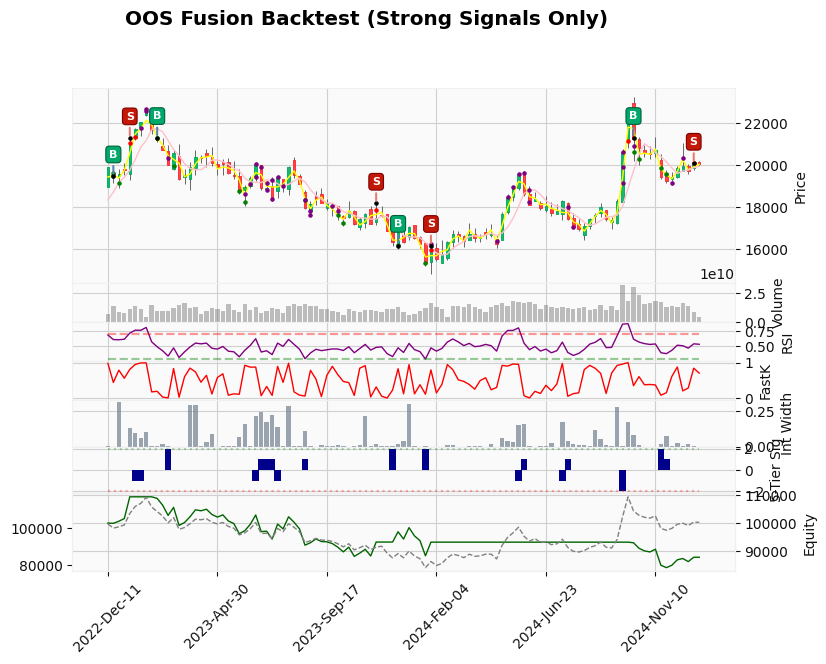

In [11]:
def run_extrema_backtest_all_signals(clean_df, test_days, mean_probs_test, fusion_model, multi_data_dict, binning_engine):
    print(f"\n--- CHECKPOINT 3: Out-of-Sample Execution (Strong Signals Only + B/S Badges) ---")

    data = clean_df.iloc[-test_days:].copy()
    min_n = min(len(data), len(mean_probs_test))
    data = data.iloc[-min_n:].copy()
    data.index = pd.to_datetime(data.index)

    test_probs = mean_probs_test[-min_n:]

    x_dict_test = {
        name: torch.tensor(multi_data_dict[name]['X_test'], dtype=torch.float32).to(DEVICE)
        for name in multi_data_dict.keys()
    }

    fusion_model.eval()
    with torch.no_grad():
        _, logits_lower, logits_upper = fusion_model(x_dict_test, return_intervals=True)
        probs_lower = F.softmax(logits_lower, dim=1).cpu().numpy()[-min_n:]
        probs_upper = F.softmax(logits_upper, dim=1).cpu().numpy()[-min_n:]

    trough_width = np.abs(probs_upper[:, 0] - probs_lower[:, 0])
    peak_width = np.abs(probs_upper[:, 1] - probs_lower[:, 1])
    widths = np.stack([trough_width, peak_width], axis=1)

    # Classify signals using the optimized binning engine
    signals, abnormalities = binning_engine.classify_signals(test_probs, widths)

    data['Signal'] = signals
    data['Abnormality'] = abnormalities
    data['Dominant_Interval_Width'] = np.where(test_probs[:, 0] >= test_probs[:, 1], trough_width, peak_width)

    cash, holdings, in_position = 100000.0, 0.0, False
    strategy_values = []

    # Signal trackers for dots
    strong_troughs, strong_peaks = [], []
    executed_buys, executed_sells = [], []
    uncertain_points = []

    start_price = data['Close'].iloc[0]
    data['Benchmark'] = data['Close'] * (100000.0 / start_price)

    for i in range(len(data)):
        curr_date = data.index[i]
        price = data['Close'].iloc[i]
        open_price = data['Open'].iloc[i]

        if i == 0:
            strategy_values.append(cash)
            continue

        prev_signal = data['Signal'].iloc[i-1]
        prev_prev_signal = data['Signal'].iloc[i-2] if i > 1 else None
        prev_abnormality = data['Abnormality'].iloc[i-1]

        # --- SIGNAL TRACKING FOR GREEN AND RED DOTS (Rising Edge Flashes) ---
        if prev_signal == 2 and prev_prev_signal != 2:
            strong_troughs.append((curr_date, price))
        elif prev_signal == -2 and prev_prev_signal != -2:
            strong_peaks.append((curr_date, price))

        if prev_abnormality != 'Normal':
            uncertain_points.append((curr_date, price))

        # --- TRADE EXECUTION (TRADES ONLY ON STRONG SIGNALS) ---
        go_long = (prev_signal == 2)          # Buy only on Strong Buy (+2)
        force_liquidate = (prev_signal == -2) # Sell only on Strong Sell (-2)

        if go_long and not in_position:
            execution_price = open_price * 1.0005
            holdings = cash / execution_price
            cash = 0.0
            in_position = True
            executed_buys.append((curr_date, execution_price))

        elif force_liquidate and in_position:
            execution_price = open_price * 0.9995
            cash = holdings * execution_price
            holdings = 0.0
            in_position = False
            executed_sells.append((curr_date, execution_price))

        strategy_values.append(cash + (holdings * price))

    data['Strategy'] = strategy_values
    strat_ret = data['Strategy'].pct_change().dropna()
    bench_ret = data['Benchmark'].pct_change().dropna()

    qs.reports.metrics(strat_ret, benchmark=bench_ret, prepare_returns=False)

    # --- Resampling Logic ---
    resample_freq = 'W'
    plot_data = data.resample(resample_freq).agg({
        'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last',
        'Volume': 'sum', '5D_MA': 'last', '20D_MA': 'last',
        'Micro_RSI': 'last', 'Micro_FastK': 'last', 'Strategy': 'last',
        'Benchmark': 'last', 'Dominant_Interval_Width': 'last', 'Signal': 'last'
    }).dropna()

    plot_dates = plot_data.index.tolist()
    def get_x_idx(target_date):
        for idx, p_date in enumerate(plot_dates):
            if p_date >= target_date: return idx
        return len(plot_dates) - 1

    strong_trough_coords = [(get_x_idx(d), p) for d, p in strong_troughs]
    strong_peak_coords   = [(get_x_idx(d), p) for d, p in strong_peaks]

    buy_coords  = [(get_x_idx(d), p) for d, p in executed_buys]
    sell_coords = [(get_x_idx(d), p) for d, p in executed_sells]
    uncertain_coords = [(get_x_idx(d), p) for d, p in uncertain_points]

    # --- Plotting Panels ---
    apds = [
        mpf.make_addplot(plot_data['5D_MA'], color='yellow', panel=0, width=1.0),
        mpf.make_addplot(plot_data['20D_MA'], color='pink', panel=0, width=1.0),
        mpf.make_addplot(plot_data['Volume'], type='bar', color='gray', panel=1, alpha=0.5, ylabel='Volume'),
        mpf.make_addplot(plot_data['Micro_RSI'], color='purple', panel=2, ylabel='RSI', width=1.0),
        mpf.make_addplot([0.70]*len(plot_data), color='red', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot([0.30]*len(plot_data), color='green', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot(plot_data['Micro_FastK'], color='red', panel=3, ylabel='FastK', width=1.0),
        mpf.make_addplot(plot_data['Dominant_Interval_Width'], type='bar', panel=4, color='slategrey', ylabel='Int Width', alpha=0.7),
        mpf.make_addplot(plot_data['Signal'], type='bar', panel=5, color='darkblue', ylabel='5-Tier Sig', width=1.2),
        mpf.make_addplot([2.0]*len(plot_data), color='green', linestyle=':', panel=5, alpha=0.3),
        mpf.make_addplot([-2.0]*len(plot_data), color='red', linestyle=':', panel=5, alpha=0.3),
        mpf.make_addplot(plot_data['Strategy'], panel=6, color='darkgreen', ylabel='Equity', width=1.0),
        mpf.make_addplot(plot_data['Benchmark'], panel=6, color='gray', linestyle='--', width=1.0)
    ]

    fig, axlist = mpf.plot(
        plot_data, type='candle', style='yahoo', addplot=apds, panel_ratios=(5, 1, 1, 1, 1.2, 1.2, 2),
        figratio=(40, 30), figscale=1.2, title='OOS Fusion Backtest (Strong Signals Only)', returnfig=True
    )

    ax_signal = axlist[5]
    ax_signal.set_yticks([-2, -1, 0, 1, 2])
    ax_signal.set_yticklabels(['Strong Sell', 'Sell', 'Hold', 'Buy', 'Strong Buy'], rotation=25, fontsize=8)

    ax_main = axlist[0]

    DOT_SIZE = 5  # Uniform size for all scatter dots

    # Green Dots for Strong Buy Signals
    for idx, price in strong_trough_coords:
        ax_main.scatter(idx, price, color='green', s=DOT_SIZE, zorder=10)

    # Red Dots for Strong Sell Signals
    for idx, price in strong_peak_coords:
        ax_main.scatter(idx, price, color='red', s=DOT_SIZE, zorder=10)

    # Purple Dots for Uncertainty Markers
    for idx, price in uncertain_coords:
        ax_main.scatter(idx, price, color='purple', s=DOT_SIZE, zorder=10, label='Uncertain/Abnormal')

    # --- RESTORED B/S ANNOTATION BADGES WITH BLACK LOCATOR DOTS ---
    bbox_buy  = dict(boxstyle="round,pad=0.3", fc="#00A86B", ec="#006039", lw=0.8)
    bbox_sell = dict(boxstyle="round,pad=0.3", fc="#C21807", ec="#800000", lw=0.8)
    arrow_buy  = dict(arrowstyle="-", color="#5B84B1", lw=1.5)
    arrow_sell = dict(arrowstyle="-", color="#E67C73", lw=1.5)

    # Black Dots + Green 'B' Badges for Buy Execution
    for idx, price in buy_coords:
        ax_main.scatter(idx, price, color='black', s=DOT_SIZE, zorder=11)
        ax_main.annotate(
            'B', xy=(idx, price), xytext=(0, 12), textcoords="offset points",
            ha="center", va="bottom", bbox=bbox_buy, arrowprops=arrow_buy,
            fontsize=8, fontweight='bold', color='white', zorder=12
        )

    # Black Dots + Red 'S' Badges for Sell Execution
    for idx, price in sell_coords:
        ax_main.scatter(idx, price, color='black', s=DOT_SIZE, zorder=11)
        ax_main.annotate(
            'S', xy=(idx, price), xytext=(0, 12), textcoords="offset points",
            ha="center", va="bottom", bbox=bbox_sell, arrowprops=arrow_sell,
            fontsize=8, fontweight='bold', color='white', zorder=12
        )

    plt.show()

# --- EXECUTION ---
run_extrema_backtest_all_signals(
    clean_df, TEST_DAYS_N, mean_probs_test_fusion, cross_asset_fusion, multi_data, best_binning_engine
)


--- CHECKPOINT 3: Out-of-Sample Trajectory Inspection (Color & Marker Separated) ---


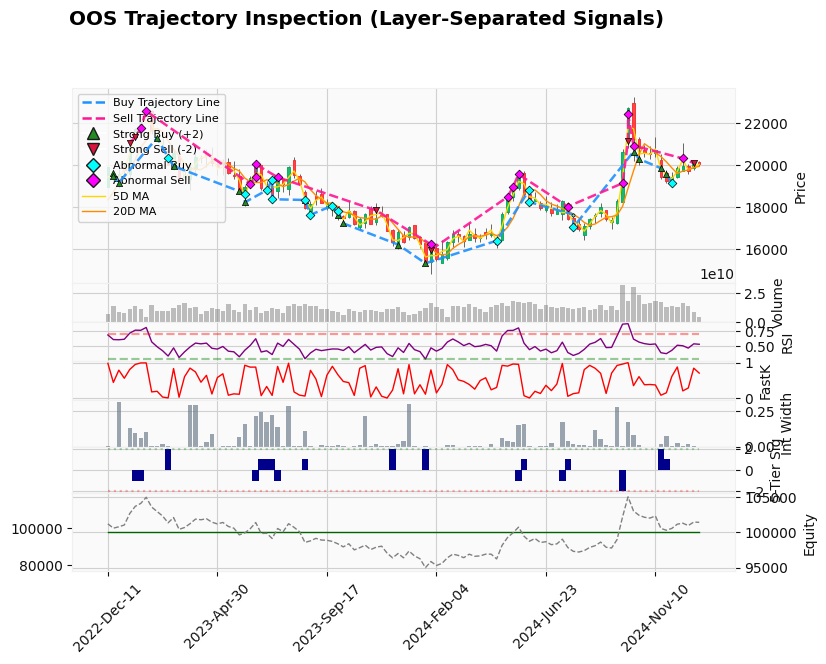

In [12]:
from matplotlib.lines import Line2D

def run_extrema_backtest_all_signals(clean_df, test_days, mean_probs_test, fusion_model, multi_data_dict, binning_engine):
    print(f"\n--- CHECKPOINT 3: Out-of-Sample Trajectory Inspection (Color & Marker Separated) ---")

    data = clean_df.iloc[-test_days:].copy()
    min_n = min(len(data), len(mean_probs_test))
    data = data.iloc[-min_n:].copy()
    data.index = pd.to_datetime(data.index)

    test_probs = mean_probs_test[-min_n:]

    x_dict_test = {
        name: torch.tensor(multi_data_dict[name]['X_test'], dtype=torch.float32).to(DEVICE)
        for name in multi_data_dict.keys()
    }

    fusion_model.eval()
    with torch.no_grad():
        _, logits_lower, logits_upper = fusion_model(x_dict_test, return_intervals=True)
        probs_lower = F.softmax(logits_lower, dim=1).cpu().numpy()[-min_n:]
        probs_upper = F.softmax(logits_upper, dim=1).cpu().numpy()[-min_n:]

    trough_width = np.abs(probs_upper[:, 0] - probs_lower[:, 0])
    peak_width = np.abs(probs_upper[:, 1] - probs_lower[:, 1])
    widths = np.stack([trough_width, peak_width], axis=1)

    # Classify signals using the binning engine
    signals, abnormalities = binning_engine.classify_signals(test_probs, widths)

    data['Signal'] = signals
    data['Abnormality'] = abnormalities
    data['Dominant_Interval_Width'] = np.where(test_probs[:, 0] >= test_probs[:, 1], trough_width, peak_width)

    cash = 100000.0
    strategy_values = []

    # Signal trackers for all categories
    strong_troughs, standard_troughs = [], []
    strong_peaks, standard_peaks = [], []
    abnormal_buys, abnormal_sells = [], []
    all_buys, all_sells = [], []

    start_price = data['Close'].iloc[0]
    data['Benchmark'] = data['Close'] * (100000.0 / start_price)

    for i in range(len(data)):
        curr_date = data.index[i]
        price = data['Close'].iloc[i]

        if i == 0:
            strategy_values.append(cash)
            continue

        prev_signal = data['Signal'].iloc[i-1]
        prev_prev_signal = data['Signal'].iloc[i-2] if i > 1 else None
        prev_abnormality = data['Abnormality'].iloc[i-1]

        # --- SIGNAL TRACKING (Rising Edge Flashes) ---
        if prev_signal != prev_prev_signal:
            if prev_signal > 0: # ANY BUY SIGNAL (+1 or +2)
                all_buys.append((curr_date, price))
                if prev_abnormality != 'Normal':
                    abnormal_buys.append((curr_date, price))
                elif prev_signal == 2:
                    strong_troughs.append((curr_date, price))
                elif prev_signal == 1:
                    standard_troughs.append((curr_date, price))

            elif prev_signal < 0: # ANY SELL SIGNAL (-1 or -2)
                all_sells.append((curr_date, price))
                if prev_abnormality != 'Normal':
                    abnormal_sells.append((curr_date, price))
                elif prev_signal == -2:
                    strong_peaks.append((curr_date, price))
                elif prev_signal == -1:
                    standard_peaks.append((curr_date, price))

        # Capital stays in 100% cash (Inspection Mode)
        strategy_values.append(cash)

    data['Strategy'] = strategy_values
    strat_ret = data['Strategy'].pct_change().dropna()
    bench_ret = data['Benchmark'].pct_change().dropna()

    # qs.reports.metrics(strat_ret, benchmark=bench_ret, prepare_returns=False)

    # --- Resampling Logic ---
    resample_freq = 'W'
    plot_data = data.resample(resample_freq).agg({
        'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last',
        'Volume': 'sum', '5D_MA': 'last', '20D_MA': 'last',
        'Micro_RSI': 'last', 'Micro_FastK': 'last', 'Strategy': 'last',
        'Benchmark': 'last', 'Dominant_Interval_Width': 'last', 'Signal': 'last'
    }).dropna()

    plot_dates = plot_data.index.tolist()
    def get_x_idx(target_date):
        for idx, p_date in enumerate(plot_dates):
            if p_date >= target_date: return idx
        return len(plot_dates) - 1

    # Scatter coordinates
    strong_trough_coords   = [(get_x_idx(d), p) for d, p in strong_troughs]
    standard_trough_coords = [(get_x_idx(d), p) for d, p in standard_troughs]
    strong_peak_coords     = [(get_x_idx(d), p) for d, p in strong_peaks]
    standard_peak_coords   = [(get_x_idx(d), p) for d, p in standard_peaks]
    abnormal_buy_coords    = [(get_x_idx(d), p) for d, p in abnormal_buys]
    abnormal_sell_coords   = [(get_x_idx(d), p) for d, p in abnormal_sells]

    # Trajectory line coordinates
    all_buys.sort(key=lambda x: x[0])
    all_sells.sort(key=lambda x: x[0])
    all_buy_coords  = [(get_x_idx(d), p) for d, p in all_buys]
    all_sell_coords = [(get_x_idx(d), p) for d, p in all_sells]

    # --- Plotting Panels ---
    # Changed 20D_MA to 'darkorange' to prevent collision with Pink Sell line
    apds = [
        mpf.make_addplot(plot_data['5D_MA'], color='gold', panel=0, width=1.0),
        mpf.make_addplot(plot_data['20D_MA'], color='darkorange', panel=0, width=1.0),
        mpf.make_addplot(plot_data['Volume'], type='bar', color='gray', panel=1, alpha=0.5, ylabel='Volume'),
        mpf.make_addplot(plot_data['Micro_RSI'], color='purple', panel=2, ylabel='RSI', width=1.0),
        mpf.make_addplot([0.70]*len(plot_data), color='red', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot([0.30]*len(plot_data), color='green', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot(plot_data['Micro_FastK'], color='red', panel=3, ylabel='FastK', width=1.0),
        mpf.make_addplot(plot_data['Dominant_Interval_Width'], type='bar', panel=4, color='slategrey', ylabel='Int Width', alpha=0.7),
        mpf.make_addplot(plot_data['Signal'], type='bar', panel=5, color='darkblue', ylabel='5-Tier Sig', width=1.2),
        mpf.make_addplot([2.0]*len(plot_data), color='green', linestyle=':', panel=5, alpha=0.3),
        mpf.make_addplot([-2.0]*len(plot_data), color='red', linestyle=':', panel=5, alpha=0.3),
        mpf.make_addplot(plot_data['Strategy'], panel=6, color='darkgreen', ylabel='Equity', width=1.0),
        mpf.make_addplot(plot_data['Benchmark'], panel=6, color='gray', linestyle='--', width=1.0)
    ]

    fig, axlist = mpf.plot(
        plot_data, type='candle', style='yahoo', addplot=apds, panel_ratios=(5, 1, 1, 1, 1.2, 1.2, 2),
        figratio=(40, 30), figscale=1.2, title='OOS Trajectory Inspection (Layer-Separated Signals)', returnfig=True
    )

    ax_signal = axlist[5]
    ax_signal.set_yticks([-2, -1, 0, 1, 2])
    ax_signal.set_yticklabels(['Strong Sell', 'Sell', 'Hold', 'Buy', 'Strong Buy'], rotation=25, fontsize=8)

    ax_main = axlist[0]

    # --- 1. DISTINCT TRAJECTORY LINES ---
    if all_buy_coords:
        bx, by = zip(*all_buy_coords)
        ax_main.plot(bx, by, color='dodgerblue', linestyle='--', linewidth=1.8, alpha=0.9, zorder=8)

    if all_sell_coords:
        sx, sy = zip(*all_sell_coords)
        ax_main.plot(sx, sy, color='deeppink', linestyle='--', linewidth=1.8, alpha=0.9, zorder=8)

    # --- 2. DISTINCT SHAPES & HIGH-CONTRAST COLORS ---
    MARKER_SIZE = 20

    # Strong Buy (+2): Green Triangle Up
    for idx, price in strong_trough_coords:
        ax_main.scatter(idx, price, color='forestgreen', marker='^', s=MARKER_SIZE, edgecolors='black', linewidths=0.5, zorder=12)

    # Standard Buy (+1): Light Green Circle
    for idx, price in standard_trough_coords:
        ax_main.scatter(idx, price, color='#85E3B3', marker='o', s=MARKER_SIZE-15, edgecolors='black', linewidths=0.5, zorder=11)

    # Strong Sell (-2): Red Triangle Down
    for idx, price in strong_peak_coords:
        ax_main.scatter(idx, price, color='crimson', marker='v', s=MARKER_SIZE, edgecolors='black', linewidths=0.5, zorder=12)

    # Standard Sell (-1): Light Red Circle
    for idx, price in standard_peak_coords:
        ax_main.scatter(idx, price, color='#E67C73', marker='o', s=MARKER_SIZE-15, edgecolors='black', linewidths=0.5, zorder=11)

    # Abnormal Buy: Cyan Diamond
    for idx, price in abnormal_buy_coords:
        ax_main.scatter(idx, price, color='cyan', marker='D', s=MARKER_SIZE, edgecolors='black', linewidths=0.5, zorder=12)

    # Abnormal Sell: Magenta Diamond
    for idx, price in abnormal_sell_coords:
        ax_main.scatter(idx, price, color='magenta', marker='D', s=MARKER_SIZE, edgecolors='black', linewidths=0.5, zorder=12)

    # --- 3. CUSTOM LEGEND TO UN-CLUTTER CHART ---
    legend_elements = [
        Line2D([0], [0], color='dodgerblue', lw=1.8, ls='--', label='Buy Trajectory Line'),
        Line2D([0], [0], color='deeppink', lw=1.8, ls='--', label='Sell Trajectory Line'),
        Line2D([0], [0], marker='^', color='w', mfc='forestgreen', mec='k', ms=8, label='Strong Buy (+2)'),
        Line2D([0], [0], marker='v', color='w', mfc='crimson', mec='k', ms=8, label='Strong Sell (-2)'),
        Line2D([0], [0], marker='D', color='w', mfc='cyan', mec='k', ms=7, label='Abnormal Buy'),
        Line2D([0], [0], marker='D', color='w', mfc='magenta', mec='k', ms=7, label='Abnormal Sell'),
        Line2D([0], [0], color='gold', lw=1, label='5D MA'),
        Line2D([0], [0], color='darkorange', lw=1, label='20D MA')
    ]
    ax_main.legend(handles=legend_elements, loc='upper left', fontsize=8, framealpha=0.85)

    plt.show()

# --- EXECUTION ---
run_extrema_backtest_all_signals(
    clean_df, TEST_DAYS_N, mean_probs_test_fusion, cross_asset_fusion, multi_data, best_binning_engine
)

## Phase VI: 13C2 Interactive Decision Surface Dashboard

### Methodology
- **Full Combination Coverage**: Visualizes 2D decision boundary slices across all $\binom{13}{2} = 78$ feature pair combinations.
- **Dynamic Input Vector Tracking**: Provides 13 baseline feature sliders. Adjusting any slider dynamically re-computes the model's prediction across the 2D surface grid ($35 \times 35 = 1,225$ vectorized GPU evaluations).
- **Live State Marker**: Plots a **Cyan Star** representing the exact location of the current 13-dimensional input vector state, displaying the live 5-tier classification tier and abnormality status in the title.

In [13]:
def create_13c2_interactive_dashboard(fusion_model, binning_engine, scaler, feature_names, X_train):
    """
    13C2 Interactive Decision Surface Dashboard:
    Visualizes 2D slices of all 78 feature combinations with a live state marker (dot)
    tracked across 13 baseline feature sliders.
    """
    # 1. Unpack feature range statistics from training data
    X_reshaped = X_train.reshape(-1, X_train.shape[2])
    X_orig = scaler.inverse_transform(X_reshaped)
    medians = np.median(X_orig, axis=0)

    # 2. Axis Selection Dropdowns (Pick 1 of 78 pairs)
    dropdown_x = widgets.Dropdown(
        options=feature_names,
        value=feature_names[0], # e.g. Micro_RSI
        description='X-Axis:',
        style={'description_width': '60px'}
    )

    dropdown_y = widgets.Dropdown(
        options=feature_names,
        value=feature_names[2], # e.g. Micro_FastK
        description='Y-Axis:',
        style={'description_width': '60px'}
    )

    # 3. Build 13 Feature Sliders
    slider_widgets = {}
    for i, f_name in enumerate(feature_names):
        f_min = float(np.min(X_orig[:, i]))
        f_max = float(np.max(X_orig[:, i]))
        f_med = float(medians[i])

        slider_widgets[f_name] = widgets.FloatSlider(
            value=f_med,
            min=f_min,
            max=f_max,
            step=(f_max - f_min) / 100.0 if f_max != f_min else 0.01,
            description=f_name,
            continuous_update=False,
            style={'description_width': '140px'},
            layout={'width': '380px'}
        )

    # 4. Update Engine
    def update_view(x_feat, y_feat, **kwargs):
        if x_feat == y_feat:
            print("⚠️ Warning: X-Axis and Y-Axis features must be different.")
            return

        idx_x = feature_names.index(x_feat)
        idx_y = feature_names.index(y_feat)

        # Build current 13D vector state from sliders
        current_13d_state = medians.copy()
        for f_name, slider in kwargs.items():
            if f_name in feature_names:
                current_13d_state[feature_names.index(f_name)] = slider

        # Current Dot Coordinates
        dot_x = current_13d_state[idx_x]
        dot_y = current_13d_state[idx_y]

        # Query Model for EXACT Signal at Current 13D Slider Position
        single_seq = np.tile(current_13d_state, (TIME_STEPS, 1))
        single_scaled = scaler.transform(single_seq)
        t_single = torch.tensor(single_scaled, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        x_dict_single = {name: t_single for name in fusion_model.template_models.keys()}

        fusion_model.eval()
        with torch.no_grad():
            l_m, l_l, l_u = fusion_model(x_dict_single, return_intervals=True)
            p_m = F.softmax(l_m, dim=1).cpu().numpy()
            p_l = F.softmax(l_l, dim=1).cpu().numpy()
            p_u = F.softmax(l_u, dim=1).cpu().numpy()

        w_single = np.stack([
            np.abs(p_u[:, 0] - p_l[:, 0]),
            np.abs(p_u[:, 1] - p_l[:, 1])
        ], axis=1)

        current_signal_tier, current_abnormality = binning_engine.classify_signals(p_m, w_single)
        signal_labels = {-2: 'Strong Sell (-2)', -1: 'Sell (-1)', 0: 'Hold (0)', 1: 'Buy (+1)', 2: 'Strong Buy (+2)'}
        curr_label = signal_labels[current_signal_tier[0]]

        # Generate 2D Background Grid
        x_min, x_max = np.percentile(X_orig[:, idx_x], [2, 98])
        y_min, y_max = np.percentile(X_orig[:, idx_y], [2, 98])

        grid_res = 35
        x_range = np.linspace(x_min, x_max, grid_res)
        y_range = np.linspace(y_min, y_max, grid_res)
        XX, YY = np.meshgrid(x_range, y_range)

        n_points = XX.size
        grid_points = np.tile(current_13d_state, (n_points, 1))
        grid_points[:, idx_x] = XX.ravel()
        grid_points[:, idx_y] = YY.ravel()

        grid_seqs = np.tile(grid_points[:, np.newaxis, :], (1, TIME_STEPS, 1))
        b_dim, t_dim, f_dim = grid_seqs.shape
        grid_seqs_scaled = scaler.transform(grid_seqs.reshape(-1, f_dim)).reshape(b_dim, t_dim, f_dim)

        t_input = torch.tensor(grid_seqs_scaled, dtype=torch.float32, device=DEVICE)
        x_dict_grid = {name: t_input for name in fusion_model.template_models.keys()}

        with torch.no_grad():
            logits_m, logits_l, logits_u = fusion_model(x_dict_grid, return_intervals=True)
            probs_m = F.softmax(logits_m, dim=1).cpu().numpy()
            probs_l = F.softmax(logits_l, dim=1).cpu().numpy()
            probs_u = F.softmax(logits_u, dim=1).cpu().numpy()

        tw = np.abs(probs_u[:, 0] - probs_l[:, 0])
        pw = np.abs(probs_u[:, 1] - probs_l[:, 1])
        widths = np.stack([tw, pw], axis=1)

        signals, _ = binning_engine.classify_signals(probs_m, widths)
        Z_signals = signals.reshape(XX.shape)

        # Discrete Palette
        cmap_colors = ['#800000', '#E67C73', '#E0E0E0', '#85E3B3', '#006039']
        cmap = mcolors.ListedColormap(cmap_colors)
        bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
        norm = mcolors.BoundaryNorm(bounds, cmap.N)

        fig, ax = plt.subplots(figsize=(9, 6.5))
        im = ax.imshow(
            Z_signals, origin='lower', aspect='auto',
            extent=[x_min, x_max, y_min, y_max],
            cmap=cmap, norm=norm
        )

        # Plot Live State Marker (Dot)
        ax.scatter(
            dot_x, dot_y,
            color='cyan', edgecolors='black', s=200, marker='*', zorder=10,
            label=f'Current State Vector ({dot_x:.3f}, {dot_y:.3f})'
        )

        cbar = fig.colorbar(im, ticks=[-2, -1, 0, 1, 2], shrink=0.85)
        cbar.ax.set_yticklabels(['Strong Sell (-2)', 'Sell (-1)', 'Hold (0)', 'Buy (+1)', 'Strong Buy (+2)'])

        ax.set_title(
            f"13C2 Combination Surface: {x_feat} vs {y_feat}\n"
            f"Current Input State Signal ➔ {curr_label} [{current_abnormality[0]}]",
            fontsize=11, fontweight='bold'
        )
        ax.set_xlabel(x_feat, fontweight='bold')
        ax.set_ylabel(y_feat, fontweight='bold')
        ax.legend(loc='upper right', framealpha=0.9)
        ax.grid(True, linestyle=':', alpha=0.4)
        plt.tight_layout()
        plt.show()

    # Bind UI Controls
    ui = widgets.interactive_output(
        update_view,
        {
            'x_feat': dropdown_x,
            'y_feat': dropdown_y,
            **slider_widgets
        }
    )

    controls_box = widgets.VBox([
        widgets.HBox([dropdown_x, dropdown_y]),
        widgets.Label("13 Input Feature Sliders (Adjusting any slider updates the live Cyan Star location):"),
        widgets.VBox(list(slider_widgets.values()), layout={'max_height': '220px', 'overflow_y': 'scroll'})
    ])

    display(controls_box, ui)

# --- EXECUTION IN COLAB ---
create_13c2_interactive_dashboard(
    cross_asset_fusion,
    best_binning_engine,
    multi_data['Target']['scaler'],
    multi_pipeline.feature_columns,
    X_train_hsi
)

Output()